<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/reinforcement_learning/policy_gradient_atari/Policy_gradient_Atari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install "gymnasium[atari]"
!pip install autorom[accept-rom-license]

import gymnasium as gym
import ale_py

gym.register_envs(ale_py)

env = gym.make("ALE/MsPacman-v5")

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
import cv2
import os

In [ ]:
def preprocess_frame(frame):
    # Преобразовать в оттенки серого
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    # Уменьшить размер до 84x84
    resized_frame = cv2.resize(gray_frame, (84, 84), interpolation=cv2.INTER_AREA)
    # Нормализация (приведение к диапазону [0, 1])
    normalized_frame = resized_frame.astype(np.float32) / 255.0
    # Выровнять в одномерный вектор
    flattened_frame = normalized_frame.flatten()
    return flattened_frame

In [ ]:
env_name = 'ALE/MsPacman-v5'
env = gym.make(env_name, render_mode='rgb_array')

n_state = preprocess_frame(env.reset()[0]).shape[0]
n_action = env.action_space.n

print(f"Размерность состояния после предобработки: {n_state}")
print(f"Количество действий: {n_action}")

Размерность состояния после предобработки: 7056
Количество действий: 9


In [ ]:
def run_episode_policy_gradient(env, weight):
    raw_state, _ = env.reset()
    state = preprocess_frame(raw_state)
    grads = []
    total_reward = 0

    rewards_per_step = []

    while True:
        state_tensor = torch.from_numpy(state).float()
        z = torch.matmul(state_tensor.unsqueeze(0), weight)
        probs = F.softmax(z, dim=-1).squeeze(0)

        action = torch.multinomial(probs, 1).item()

        log_prob = torch.log(probs[action])
        if not weight.is_leaf or not weight.requires_grad:
            weight = weight.clone().detach().requires_grad_(True)

        log_prob.backward(retain_graph=True)
        grads.append(weight.grad.clone())
        weight.grad.zero_()

        raw_next_state, reward, done, truncated, _ = env.step(action)
        next_state = preprocess_frame(raw_next_state)

        rewards_per_step.append(reward)
        total_reward += reward
        state = next_state

        if done or truncated:
            break

    return total_reward, grads, rewards_per_step

In [ ]:
n_episode = 50 # Для уменьшения времени ожидания
learning_rate = 0.1 # Для проверки

weight = torch.rand(n_state, n_action, requires_grad=True)

total_rewards = []
best_total_reward = -float('inf')
best_weight = None

for episode in range(n_episode):
    total_reward, gradients, rewards_per_step = run_episode_policy_gradient(env, weight)
    total_rewards.append(total_reward)

    for t, grad in enumerate(gradients):
        R_t = sum(rewards_per_step[t:])

        weight.data += learning_rate * grad * R_t

    print(f'Эпизод {episode + 1}: Вознаграждение = {total_reward:.2f}')

    if total_reward > best_total_reward:
        best_total_reward = total_reward
        best_weight = weight.clone().detach()

Эпизод 1: Вознаграждение = 240.00
Эпизод 2: Вознаграждение = 70.00
Эпизод 3: Вознаграждение = 70.00
Эпизод 4: Вознаграждение = 70.00
Эпизод 5: Вознаграждение = 70.00
Эпизод 6: Вознаграждение = 70.00
Эпизод 7: Вознаграждение = 70.00
Эпизод 8: Вознаграждение = 70.00
Эпизод 9: Вознаграждение = 70.00
Эпизод 10: Вознаграждение = 70.00
Эпизод 11: Вознаграждение = 70.00
Эпизод 12: Вознаграждение = 70.00
Эпизод 13: Вознаграждение = 70.00
Эпизод 14: Вознаграждение = 70.00
Эпизод 15: Вознаграждение = 70.00
Эпизод 16: Вознаграждение = 70.00
Эпизод 17: Вознаграждение = 70.00
Эпизод 18: Вознаграждение = 70.00
Эпизод 19: Вознаграждение = 70.00
Эпизод 20: Вознаграждение = 70.00
Эпизод 21: Вознаграждение = 70.00
Эпизод 22: Вознаграждение = 70.00
Эпизод 23: Вознаграждение = 70.00
Эпизод 24: Вознаграждение = 70.00
Эпизод 25: Вознаграждение = 70.00
Эпизод 26: Вознаграждение = 70.00
Эпизод 27: Вознаграждение = 70.00
Эпизод 28: Вознаграждение = 70.00
Эпизод 29: Вознаграждение = 70.00
Эпизод 30: Вознагражде

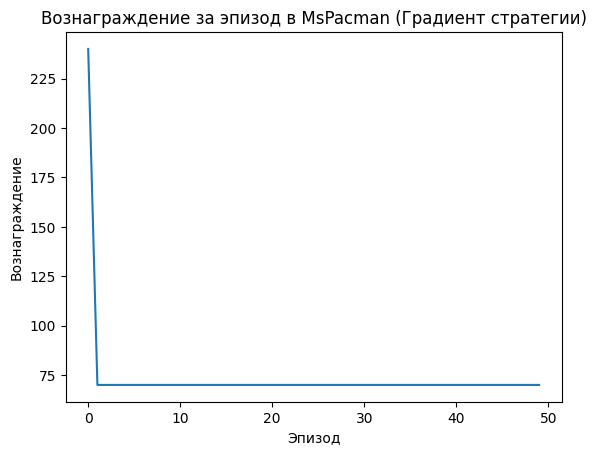

In [ ]:
plt.plot(total_rewards)
plt.xlabel('Эпизод')
plt.ylabel('Вознаграждение')
plt.title('Вознаграждение за эпизод в MsPacman (Градиент стратегии)')
plt.show()

In [ ]:
from gymnasium.wrappers import RecordVideo

eval_env = gym.make(env_name, render_mode='rgb_array')

video_folder = './ms_pacman_policy_gradient_video'
if not os.path.exists(video_folder):
    os.makedirs(video_folder)

for i in range(3):
    current_video_folder = os.path.join(video_folder, f'episode_{i+1}')
    if not os.path.exists(current_video_folder):
        os.makedirs(current_video_folder)

    wrapped_env = RecordVideo(gym.make(env_name, render_mode='rgb_array'), current_video_folder)

    raw_state, _ = wrapped_env.reset()
    state = preprocess_frame(raw_state)
    done = False
    truncated = False
    episode_reward = 0

    with torch.no_grad():
        while not done and not truncated:
            state_tensor = torch.from_numpy(state).float()
            z = torch.matmul(state_tensor.unsqueeze(0), best_weight.detach())
            probs = F.softmax(z, dim=-1).squeeze(0)
            action = torch.argmax(probs).item()

            raw_next_state, reward, done, truncated, _ = wrapped_env.step(action)
            state = preprocess_frame(raw_next_state)
            episode_reward += reward

    wrapped_env.close()
    print(f"Тестовый эпизод {i+1} завершен с вознаграждением: {episode_reward}")

env.close()

print(f"Видеозаписи эпизодов сохранены в папках внутри: {video_folder}")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/ms_pacman_policy_gradient_video/episode_1 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Тестовый эпизод 1 завершен с вознаграждением: 70.0


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/ms_pacman_policy_gradient_video/episode_2 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Тестовый эпизод 2 завершен с вознаграждением: 70.0


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/ms_pacman_policy_gradient_video/episode_3 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Тестовый эпизод 3 завершен с вознаграждением: 70.0
Видеозаписи эпизодов сохранены в папках внутри: ./ms_pacman_policy_gradient_video


Получили следующий результат: первая эпоха имеет больше очков, чем все последующие. По видео заметим, что пакмен перемещается в угол, по пути набирая те самые 70 очков. Затем он стоит там, пока его не найдет привидение. Первый результат выбивается из статистики, т.к. изначально веса случайны, и пакман натыкается на многие точки. После первой итерации обучения появляется маршрут движения, в результате которого пакман дольше не сталкивается с привидением -> дольше "живет", в итоге этот шаблон закрепляется, и нет достаточных по очкам стимулов для того, чтобы "выбить" нейросеть с этого пути.